importing Jupyter notebook from file_1_data_processing.ipynb
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             int64  
 1   date           object 
 2   store_nbr      int64  
 3   product_type   object 
 4   sales          float64
 5   special_offer  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
[ 1 10 11 12 13 14 15 16 17 18 19  2 20 21 22 23 24 25 26 27 28 29  3 30
 31 

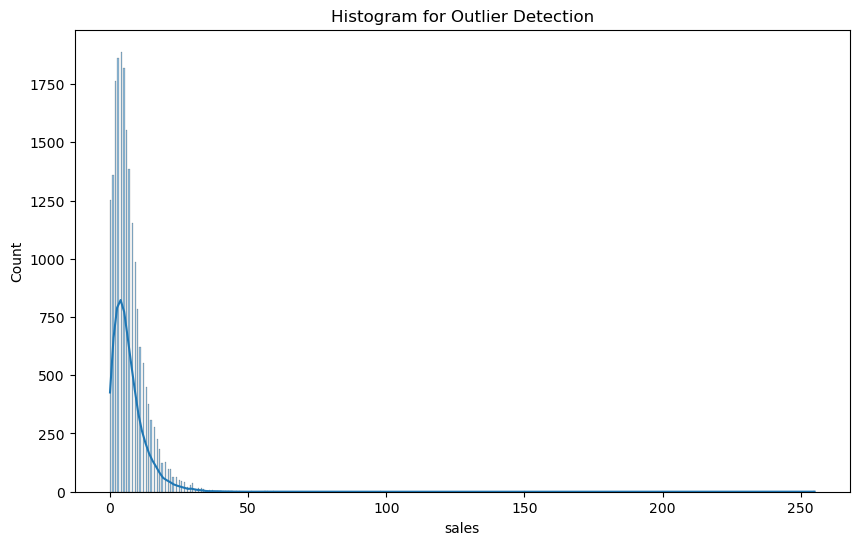

importing Jupyter notebook from file_2_features_selection.ipynb
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 07 Dec 2023   Prob (F-statistic):                nan
Time:                        16:32:59   Log-Likelihood:            -5.5829e+06
No. Observations:              650430   AIC:                         1.117e+07
Df Residuals:                  650429   BIC:                         1.117e+07
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [ ]:
import import_ipynb
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from file_1_data_processing import *
from file_2_features_selection import *

3.1. Divide the test set into subsets of products and stores

In [ ]:
data_test_1 = data_test.copy()

# List to store subsets with lagged features
lagged_subsets = []

for product in products:
    for store in stores:
        # Filter data for the current product and store
        condition = (data_test['product_type'] == product) & (data_test['store_nbr'] == store)
        subset = data_test.loc[condition].copy()
        
        lagged_subsets.append(subset)

# Using Linear model for prediction

3.2. Predict using linear model

In [10]:
#Use the Linear Regression model on raw data with 14 lagged sales and offer
#Set Train data
X_train = data_train.iloc[:,6:34:2]
y_train = data_train['sales']
        
# Initialize a model
final_model = LinearRegression()

# Train the model on the historical data from 2016
final_model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Specify the date range for training and testing
start_date_test = pd.to_datetime('2017-07-31')
end_date_test = pd.to_datetime('2017-08-15')

predicted_sales = []

for subset in (lagged_subsets):
    # Initialize test_data once for the entire subset
    subset_test = subset.copy()

    for day in pd.date_range(start=start_date_test, end=end_date_test):
        test_data = subset_test[subset_test['date'] <= day].copy()
        num_lags = 14
        for i in range(1, num_lags + 1):
            test_data[f'sales_lag_{i}'] = test_data['sales'].shift(i)

        # Drop rows with NaN values resulting from lagged shifting
        test_data = test_data.fillna(0)

        #Make X_test
        x = test_data.drop(['id','store_nbr','product_type','sales','special_offer'],axis=1)
        X_test = x[x['date'] == day].drop('date',axis = 1)
        
        #Initiate the predictions
        predictions = final_model.predict(X_test)

        #Update the subset
        subset_test.loc[subset['date'] == day, 'sales'] = predictions
    
    #Retain the only part from 31/07/2017 onward
    subset_test = subset_test[subset_test['date'] >= start_date_test]
    # Replace the old subset with the updated one in lagged_subsets
    predicted_sales.append(subset_test)

In [31]:
#Checking the prediction results
predicted_sales[1000]

,id,date,store_nbr,product_type,sales,special_offer
date,,,,,,
2017-07-31,2973318,2017-07-31,35,HOME CARE,103.787970,7
2017-08-01,2975100,2017-08-01,35,HOME CARE,105.140807,5
2017-08-02,2976882,2017-08-02,35,HOME CARE,94.665731,5
2017-08-03,2978664,2017-08-03,35,HOME CARE,79.191962,6
2017-08-04,2980446,2017-08-04,35,HOME CARE,87.474228,6
2017-08-05,2982228,2017-08-05,35,HOME CARE,113.171921,5
2017-08-06,2984010,2017-08-06,35,HOME CARE,142.814843,6
2017-08-07,2985792,2017-08-07,35,HOME CARE,113.753551,5
2017-08-08,2987574,2017-08-08,35,HOME CARE,120.804224,4


In [32]:
#Compare with actual sales for HOME CARE at store 35
condition = (data_test['product_type'] == "HOME CARE") & (data_test['store_nbr'] == 35) & (data_test['date'] >= start_date_test)
data_test.loc[condition, subset.columns]

,id,date,store_nbr,product_type,sales,special_offer
date,,,,,,
2017-07-31,2973318,2017-07-31,35,HOME CARE,159.0,7
2017-08-01,2975100,2017-08-01,35,HOME CARE,131.0,5
2017-08-02,2976882,2017-08-02,35,HOME CARE,125.0,5
2017-08-03,2978664,2017-08-03,35,HOME CARE,110.0,6
2017-08-04,2980446,2017-08-04,35,HOME CARE,107.0,6
2017-08-05,2982228,2017-08-05,35,HOME CARE,110.0,5
2017-08-06,2984010,2017-08-06,35,HOME CARE,97.0,6
2017-08-07,2985792,2017-08-07,35,HOME CARE,105.0,5
2017-08-08,2987574,2017-08-08,35,HOME CARE,84.0,4


<Axes: xlabel='date'>

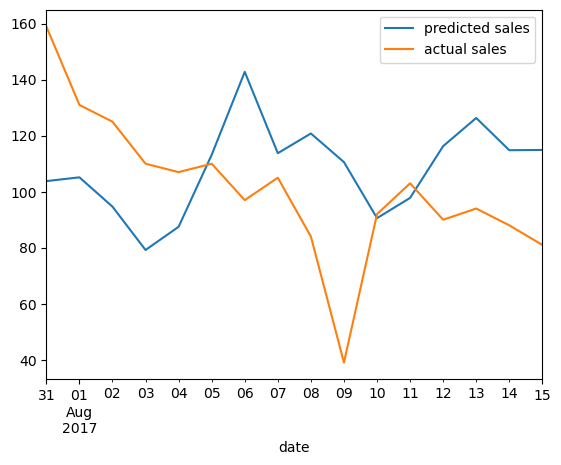

In [34]:
pred_sales_ex = predicted_sales[1000]['sales'].rename('predicted sales')
actual_sales_ex = data_test.loc[condition, subset.columns]['sales'].rename('actual sales')
example = pd.concat([pred_sales_ex,actual_sales_ex], axis = 1)
example.plot()

In [62]:
predicted_sales_df = pd.concat(predicted_sales, ignore_index=True)

# Sort the DataFrame by id
predicted_sales_df.sort_values(by=['id'], inplace=True)
predicted_sales_df['date'] = pd.to_datetime(predicted_sales_df['date'])
predicted_sales_df.index = pd.to_datetime(predicted_sales_df['date'])

#Rename column
predicted_sales_df.rename(columns={'sales': 'forecasted_sales'}, inplace=True)

# Display the resulting DataFrame
predicted_sales_df

,id,date,store_nbr,product_type,forecasted_sales,special_offer
date,,,,,,
2017-07-31,2972376,2017-07-31,1,AUTOMOTIVE,7.128525,0
2017-07-31,2972377,2017-07-31,1,BABY CARE,3.667365,0
2017-07-31,2972378,2017-07-31,1,BEAUTY,7.003723,0
2017-07-31,2972379,2017-07-31,1,BEVERAGES,2099.360513,24
2017-07-31,2972380,2017-07-31,1,BOOKS,3.981756,0
...,...,...,...,...,...,...
2017-08-15,3000883,2017-08-15,9,POULTRY,377.045888,0
2017-08-15,3000884,2017-08-15,9,PREPARED FOODS,105.496222,1
2017-08-15,3000885,2017-08-15,9,PRODUCE,1706.686717,148


In [16]:
forecasted_sales = predicted_sales_df['forecasted_sales']
actual_sales = data_test[data_test['date'] >= start_date_test]['sales']

In [14]:
forecasted_sales

date
2017-07-31       3.949892
2017-07-31       0.601300
2017-07-31       4.518346
2017-07-31    2071.656000
2017-07-31       0.893899
                 ...     
2017-08-15     397.861458
2017-08-15     102.497154
2017-08-15    2332.592226
2017-08-15      62.503712
2017-08-15      16.316149
Name: sales, Length: 28512, dtype: float64

In [15]:
actual_sales

date
2017-07-31       8.000
2017-07-31       0.000
2017-07-31       3.000
2017-07-31    2414.000
2017-07-31       1.000
                ...   
2017-08-15     438.133
2017-08-15     154.553
2017-08-15    2419.729
2017-08-15     121.000
2017-08-15      16.000
Name: sales, Length: 28512, dtype: float64

# Evaluation of results

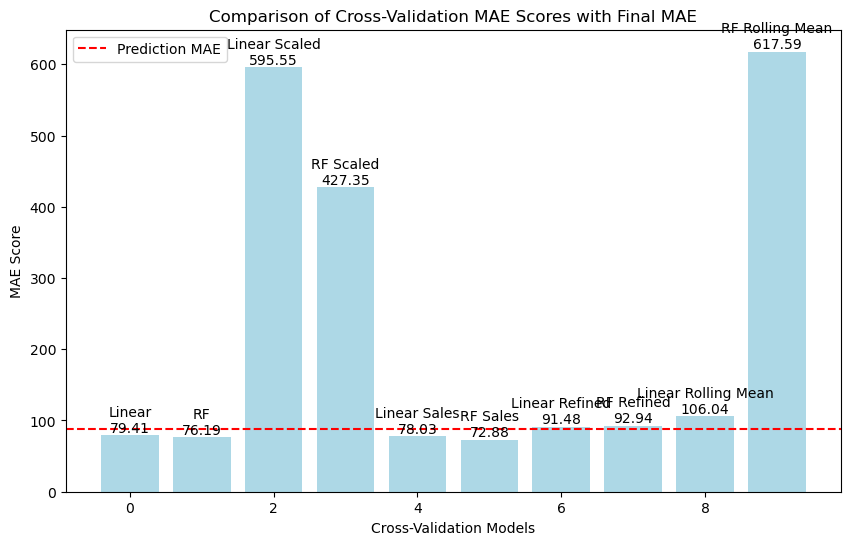

88.4025785076137

In [38]:
#Evaluation using MAE
from sklearn.metrics import mean_absolute_error

pred_mae = mean_absolute_error(actual_sales, forecasted_sales)
cv_mae_scores = [mean_mae_linear, mean_mae_RF, mae_linear_scaled, mae_RF_scaled, mae_linear_sales, mae_RF_sales, mae_linear_refined, mae_RF_refined, mae_linear_rmean, mae_RF_rmean]  # Replace with your actual cross-validation scores
cv_labels = ['Linear', 'RF', 'Linear Scaled', 'RF Scaled', 'Linear Sales', 'RF Sales', 'Linear Refined', 'RF Refined', 'Linear Rolling Mean', 'RF Rolling Mean']

# Create a bar plot to compare cross-validation scores with final MAE
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting cross-validation scores
bars = ax.bar(np.arange(len(cv_mae_scores)), cv_mae_scores, color='lightblue')

# Plotting final MAE
ax.axhline(pred_mae, color='red', linestyle='--', label='Prediction MAE')

# Adding labels for each bar
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{cv_labels[i]}\n{cv_mae_scores[i]:.2f}', ha='center', va='bottom')

# Adding labels and title
ax.set_xlabel('Cross-Validation Models')
ax.set_ylabel('MAE Score')
ax.set_title('Comparison of Cross-Validation MAE Scores with Final MAE')

# Adding legend
ax.legend()

# Show the plot
plt.show()
pred_mae

In [ ]:
#Evaluation using MSE
from sklearn.metrics import mean_squared_error

pred_mse = mean_squared_error(actual_sales, forecasted_sales)
cv_mse_scores = [mean_mse_linear, mean_mse_RF, mse_linear_scaled, mse_RF_scaled, mse_linear_sales, mse_RF_sales, mse_linear_refined, mse_RF_refined, mse_linear_rmean, mse_RF_rmean]  # Replace with your actual cross-validation scores
cv_labels = ['Linear', 'RF', 'Linear Scaled', 'RF Scaled', 'Linear Sales', 'RF Sales', 'Linear Refined', 'RF Refined', 'Linear Rolling Mean', 'RF Rolling Mean']

# Create a bar plot to compare cross-validation scores with final MSE
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting cross-validation scores
bars = ax.bar(np.arange(len(cv_mse_scores)), cv_mse_scores, color='lightblue')

# Plotting final MSE
ax.axhline(pred_mse, color='red', linestyle='--', label='Prediction MSE')

# Adding labels for each bar
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{cv_labels[i]}\n{cv_mse_scores[i]:.2f}', ha='center', va='bottom')

# Adding labels and title
ax.set_xlabel('Cross-Validation Models')
ax.set_ylabel('MSE Score')
ax.set_title('Comparison of Cross-Validation MSE Scores with Final R2')

# Adding legend
ax.legend()

# Show the plot
plt.show()
pred_mse

In [19]:
#Evaluation using RMSE
import numpy as np

pred_rmse = np.sqrt(mean_squared_error(actual_sales, forecasted_sales))
pred_rmse

279.6806219744167

In [20]:
#Evaluation using MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape = mean_absolute_percentage_error(actual_sales, forecasted_sales)
mape

inf

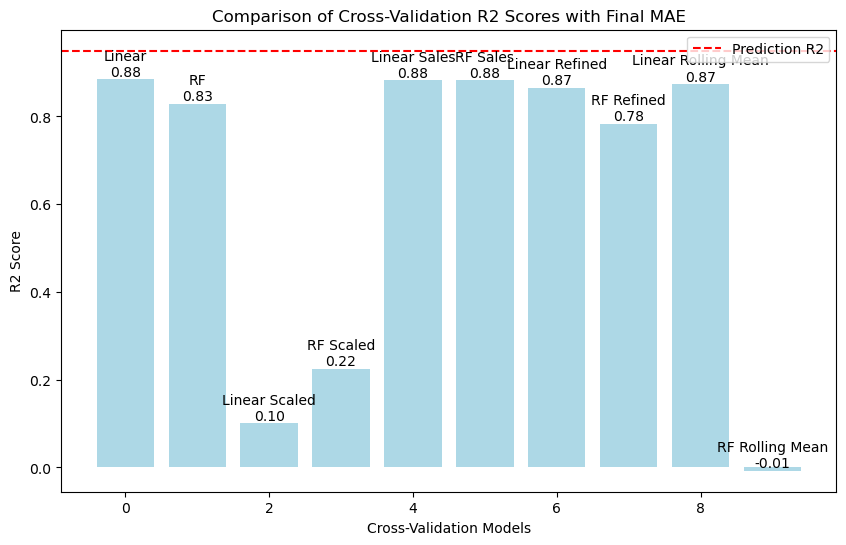

0.9498074484157286

In [41]:
#Evaluation using R2
from sklearn.metrics import r2_score

pred_r2 = r2_score(actual_sales, forecasted_sales)
cv_r2_scores = [mean_r2_linear, mean_r2_RF, r2_linear_scaled, r2_RF_scaled, r2_linear_sales, r2_RF_sales, r2_linear_refined, r2_RF_refined, r2_linear_rmean, r2_RF_rmean]  # Replace with your actual cross-validation scores
cv_labels = ['Linear', 'RF', 'Linear Scaled', 'RF Scaled', 'Linear Sales', 'RF Sales', 'Linear Refined', 'RF Refined', 'Linear Rolling Mean', 'RF Rolling Mean']

# Create a bar plot to compare cross-validation scores with final R2
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting cross-validation scores
bars = ax.bar(np.arange(len(cv_r2_scores)), cv_r2_scores, color='lightblue')

# Plotting final R2
ax.axhline(pred_r2, color='red', linestyle='--', label='Prediction R2')

# Adding labels for each bar
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{cv_labels[i]}\n{cv_r2_scores[i]:.2f}', ha='center', va='bottom')

# Adding labels and title
ax.set_xlabel('Cross-Validation Models')
ax.set_ylabel('R2 Score')
ax.set_title('Comparison of Cross-Validation R2 Scores with Final R2')

# Adding legend
ax.legend()

# Show the plot
plt.show()

pred_r2

# Performance on training data for comparison

In [45]:
# Predictions on the training set
y_train_pred = final_model.predict(X_train)

# Evaluate performance metrics
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("Mean Squared Error (MSE) on Training Set:", mse_train)
print("Mean Absolute Error (MAE) on Training Set:", mae_train)
print("R-squared (R2) on Training Set:", r2_train)

Mean Squared Error (MSE) on Training Set: 162225.9312064276
Mean Absolute Error (MAE) on Training Set: 74.57938836752795
R-squared (R2) on Training Set: 0.9027772254650284


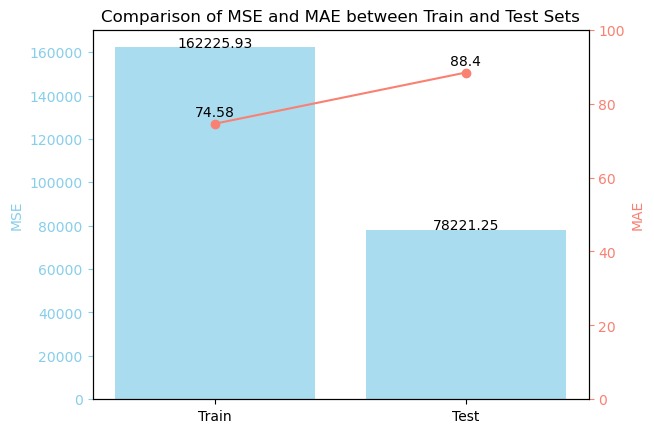

In [52]:
# Plotting
fig, ax1 = plt.subplots()

# Bar plot for MSE
ax1.bar(['Train', 'Test'], [mse_train, pred_mse], color='skyblue', alpha=0.7, label='MSE')
ax1.set_ylabel('MSE', color='skyblue')
ax1.tick_params('y', colors='skyblue')

# Create a second y-axis for MAE
ax2 = ax1.twinx()
ax2.plot(['Train', 'Test'], [mae_train, pred_mae], color='salmon', marker='o', label='MAE')
ax2.set_ylabel('MAE', color='salmon')
ax2.tick_params('y', colors='salmon')
ax2.set_ylim(0, 100)  # Set the y-axis interval for MAE

# Add data labels
for i, v in enumerate([mse_train, pred_mse]):
    ax1.text(i, v + 0.05, str(round(v, 2)), color='black', ha='center')

for i, v in enumerate([mae_train, pred_mae]):
    ax2.text(i, v + 2, str(round(v, 2)), color='black', ha='center')

plt.title('Comparison of MSE and MAE between Train and Test Sets')
plt.show()